## 13-statement-gbm


=== learning_rate = 1 ===
      Iter       Train Loss   Remaining Time 
         1           1.0190           14.15s
         2           0.9192           13.15s
         3           0.8272           12.38s
         4           0.7834           11.59s
         5           0.7109           11.40s
         6           0.6368           11.56s
         7           0.5797           11.54s
         8           0.5610           11.23s
         9           0.5185           10.97s
        10           0.4984           10.74s
        20           0.1999           11.15s
        30           0.1313           11.26s
        40           0.0790           10.57s
        50           0.0511           11.11s
        60           0.0352           10.36s
        70           0.0245            9.83s
        80           0.0162            9.21s
        90           0.0114            9.05s
       100           0.0077            8.45s
       200           0.0002            3.06s
Лучшее log-loss на тесте: 0

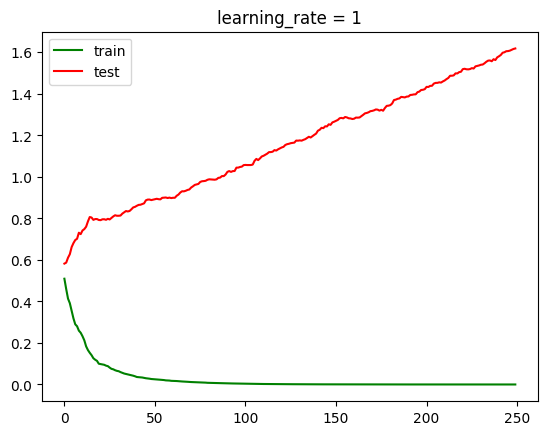


=== learning_rate = 0.5 ===
      Iter       Train Loss   Remaining Time 
         1           1.1255            9.06s
         2           1.0035            9.07s
         3           0.9386            9.13s
         4           0.8844            9.31s
         5           0.8381           10.71s
         6           0.7995           11.34s
         7           0.7559           11.78s
         8           0.7205           12.11s
         9           0.6958           12.82s
        10           0.6725           13.45s
        20           0.4672           13.99s
        30           0.3179           14.20s
        40           0.2274           12.97s
        50           0.1774           11.51s
        60           0.1394           11.05s
        70           0.1050           10.38s
        80           0.0805            9.60s
        90           0.0650            8.96s
       100           0.0511            8.33s
       200           0.0058            3.02s
Лучшее log-loss на тесте:

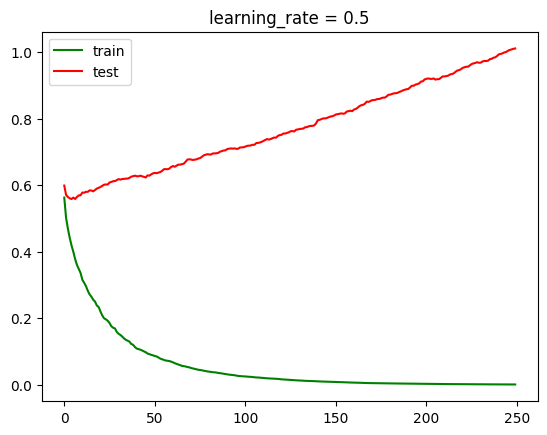


=== learning_rate = 0.3 ===
      Iter       Train Loss   Remaining Time 
         1           1.2095           12.56s
         2           1.1006           16.92s
         3           1.0240           14.02s
         4           0.9729           12.90s
         5           0.9387           13.22s
         6           0.8948           13.75s
         7           0.8621           13.75s
         8           0.8360           13.52s
         9           0.8171           13.04s
        10           0.7883           12.48s
        20           0.6164           11.59s
        30           0.4933           10.34s
        40           0.4248            9.89s
        50           0.3345            9.09s
        60           0.2760            8.35s
        70           0.2263            7.64s
        80           0.1971            7.30s
        90           0.1693            7.03s
       100           0.1388            6.53s
       200           0.0294            2.14s
Лучшее log-loss на тесте:

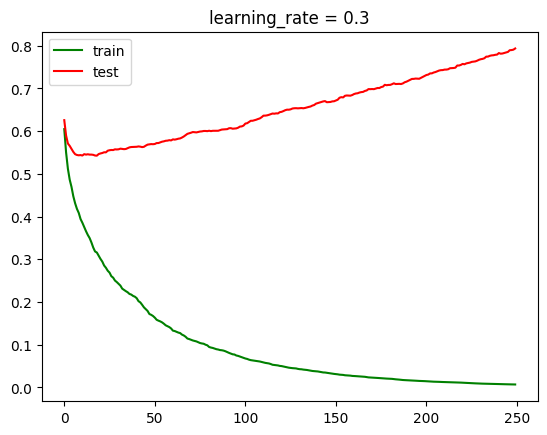


=== learning_rate = 0.2 ===
      Iter       Train Loss   Remaining Time 
         1           1.2613            9.31s
         2           1.1715            9.38s
         3           1.1009            9.48s
         4           1.0529           10.07s
         5           1.0130           10.38s
         6           0.9740           10.52s
         7           0.9475           10.44s
         8           0.9197           10.55s
         9           0.8979           11.91s
        10           0.8730           13.23s
        20           0.7207           19.88s
        30           0.6055           25.53s
        40           0.5244           24.56s
        50           0.4501           23.45s
        60           0.3908           22.98s
        70           0.3372           21.95s
        80           0.3009           20.73s
        90           0.2603           19.34s
       100           0.2327           18.12s
       200           0.0835            5.98s
Лучшее log-loss на тесте:

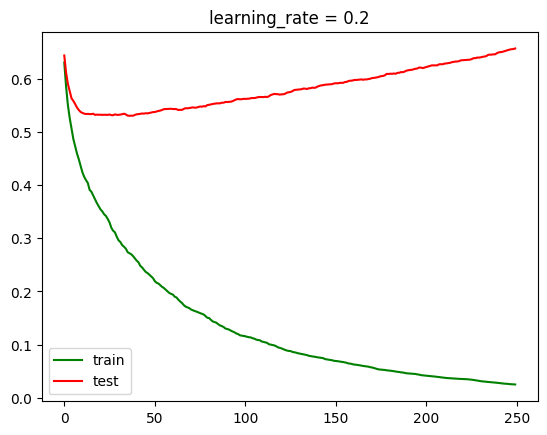


=== learning_rate = 0.1 ===
      Iter       Train Loss   Remaining Time 
         1           1.3199           18.44s
         2           1.2645           17.26s
         3           1.2170           16.21s
         4           1.1775           16.05s
         5           1.1404           16.53s
         6           1.1106           17.06s
         7           1.0844           16.18s
         8           1.0617           15.26s
         9           1.0411           14.45s
        10           1.0223           13.86s
        20           0.8864           11.27s
        30           0.7844           10.48s
        40           0.7176           10.06s
        50           0.6590            9.18s
        60           0.6120            8.50s
        70           0.5599            7.72s
        80           0.5242            7.24s
        90           0.4829            7.04s
       100           0.4473            6.64s
       200           0.2379            2.10s
Лучшее log-loss на тесте:

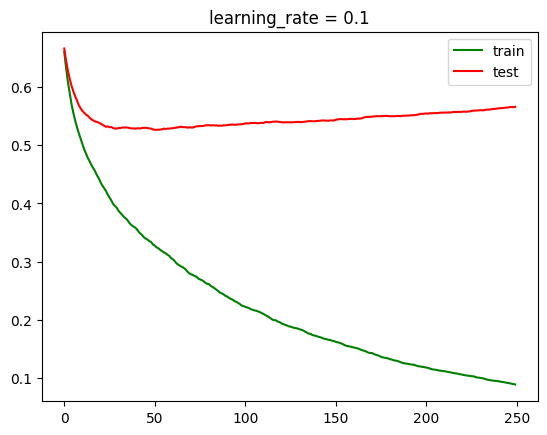


Для learning_rate = 0.2:
Минимальный log-loss на тесте = 0.530519 на итерации 37
Log-loss случайного леса (n_estimators=37): 0.541094


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import log_loss

#  Загрузка данных

data = pd.read_csv('gbm-data.csv')
X = data.iloc[:, 1:].values   # все колонки кроме первой – признаки
y = data.iloc[:, 0].values     # первая колонка – целевая переменная

# Разбиение на обучающую (20%) и тестовую (80%) выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.8, random_state=241
)


#  Перебор learning_rate [1, 0.5, 0.3, 0.2, 0.1]

learning_rates = [1, 0.5, 0.3, 0.2, 0.1]
best_iterations = {}
best_logloss = {}

for lr in learning_rates:
    print(f"\n=== learning_rate = {lr} ===")
    gbc = GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=lr,
        random_state=241,
        verbose=True
    )
    gbc.fit(X_train, y_train)
    
    # staged_decision_function возвращает отступ (decision function)
    # преобразуем в вероятности через сигмоиду
    train_scores = gbc.staged_decision_function(X_train)
    test_scores = gbc.staged_decision_function(X_test)
    
    train_logloss = []
    test_logloss = []
    
    for pred_train, pred_test in zip(train_scores, test_scores):
        # сигмоида: 1 / (1 + exp(-y_pred))
        prob_train = 1.0 / (1.0 + np.exp(-pred_train))
        prob_test  = 1.0 / (1.0 + np.exp(-pred_test))
        train_logloss.append(log_loss(y_train, prob_train))
        test_logloss.append(log_loss(y_test, prob_test))
    
    # Находим минимальное значение и итерацию
    min_test = min(test_logloss)
    iter_min = test_logloss.index(min_test) + 1  # итерации с 1
    print(f"Лучшее log-loss на тесте: {min_test:.6f} на итерации {iter_min}")
    
    best_logloss[lr] = min_test
    best_iterations[lr] = iter_min
    
    # Построение графика (опционально)
    import matplotlib.pyplot as plt
    plt.figure()
    plt.plot(train_logloss, 'g', label='train')
    plt.plot(test_logloss, 'r', label='test')
    plt.legend()
    plt.title(f'learning_rate = {lr}')
    plt.show()

# ============================================================
# 3. Характер графика качества на тесте (overfitting / underfitting)
# ============================================================
# Обычно для большинства learning_rate наблюдается переобучение
# начиная с некоторой итерации. Ответ: overfitting.

# ============================================================
# 4. Для learning_rate = 0.2 выводим результат
# ============================================================
lr_target = 0.2
min_logloss = best_logloss[lr_target]
iter_min = best_iterations[lr_target]
print(f"\nДля learning_rate = {lr_target}:")
print(f"Минимальный log-loss на тесте = {min_logloss:.6f} на итерации {iter_min}")

# ============================================================
# 5. Случайный лес с числом деревьев = iter_min
# ============================================================
rf = RandomForestClassifier(n_estimators=iter_min, random_state=241)
rf.fit(X_train, y_train)
pred_rf = rf.predict_proba(X_test)[:, 1]   # вероятность положительного класса
rf_logloss = log_loss(y_test, pred_rf)
print(f"Log-loss случайного леса (n_estimators={iter_min}): {rf_logloss:.6f}")

# ============================================================
# Ответы на задание:
# 3) overfitting
# 4) <значение log-loss> <номер итерации>
# 5) <значение log-loss случайного леса>
# ============================================================